In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [4]:
df = pd.read_csv("/content/ABC Company_Ltd..csv")
print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 7043
Columns: 21


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, 1):
    print(i, "-", column)

Columns in the dataset:

1 - customerID
2 - gender
3 - SeniorCitizen
4 - Partner
5 - Dependents
6 - tenure
7 - PhoneService
8 - MultipleLines
9 - InternetService
10 - OnlineSecurity
11 - OnlineBackup
12 - DeviceProtection
13 - TechSupport
14 - StreamingTV
15 - StreamingMovies
16 - Contract
17 - PaperlessBilling
18 - PaymentMethod
19 - MonthlyCharges
20 - TotalCharges
21 - Churn


In [9]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage Missing": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary

,Missing Values,Percentage Missing
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(
    "Missing values in TotalCharges:",
    df["TotalCharges"].isnull().sum()
)

Missing values in TotalCharges: 11


In [11]:
initial_rows = len(df)

df = df.dropna(
    subset=["TotalCharges"]
).copy()

removed_rows = initial_rows - len(df)

print("Rows before cleaning:", initial_rows)
print("Rows removed:", removed_rows)
print("Rows after cleaning:", len(df))

Rows before cleaning: 7043
Rows removed: 11
Rows after cleaning: 7032


In [12]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [13]:
for column in df.columns:
    print("\n" + "="*50)
    print(column)
    print(df[column].unique()[:15])


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU'
 '9763-GRSKD' '7469-LKBCI' '8091-TTVAX' '0280-XJGEX' '5129-JLPIS']

gender
['Female' 'Male']

SeniorCitizen
[0 1]

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69]

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

MonthlyCharges
[ 29.85  56.95  5

In [14]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

print("\nPercentage distribution:")
print(
    (df["Churn"].value_counts(normalize=True) * 100).round(2)
)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage distribution:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


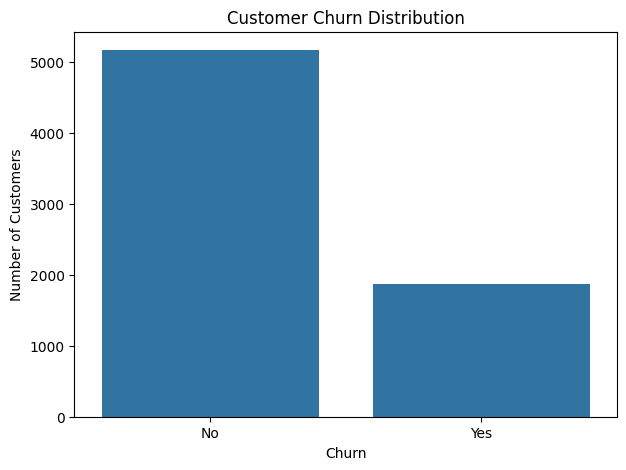

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

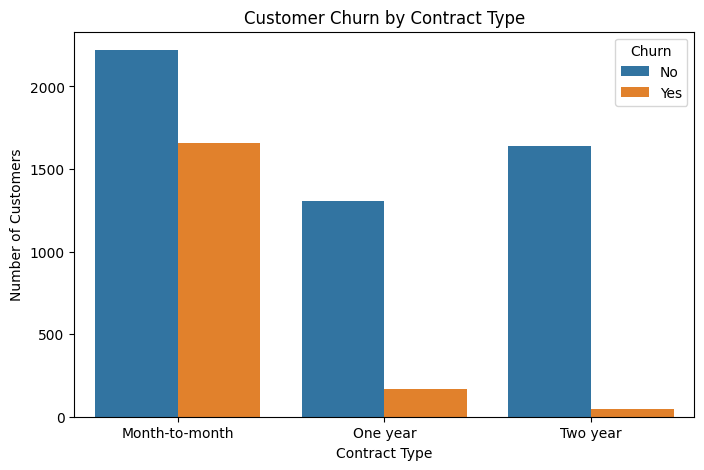

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [17]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


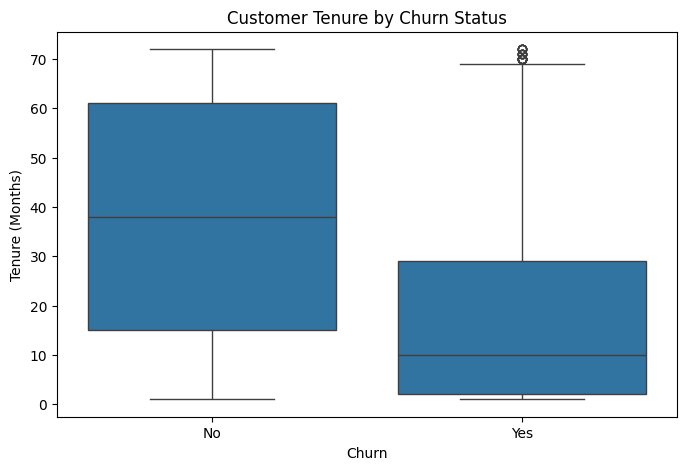

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

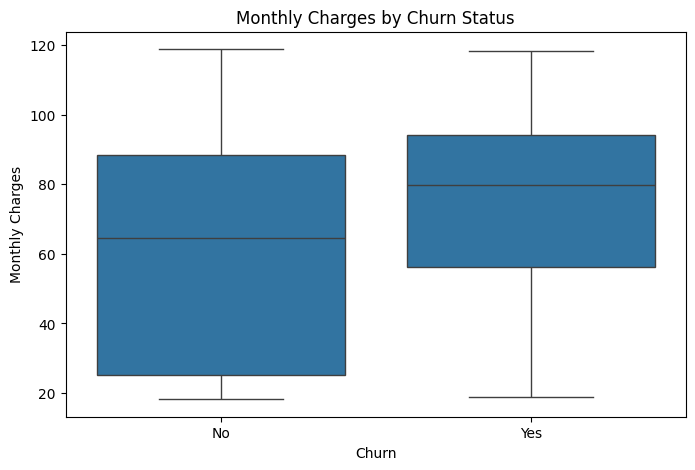

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

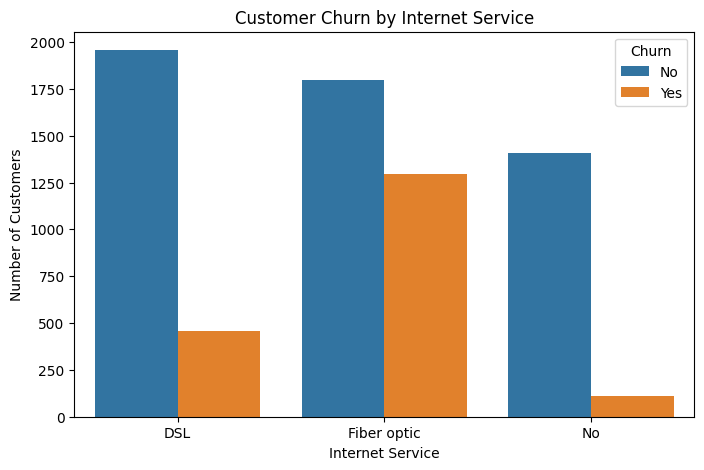

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

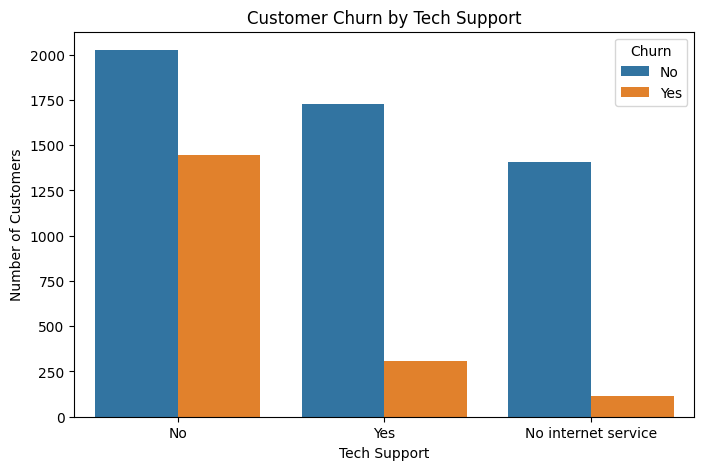

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

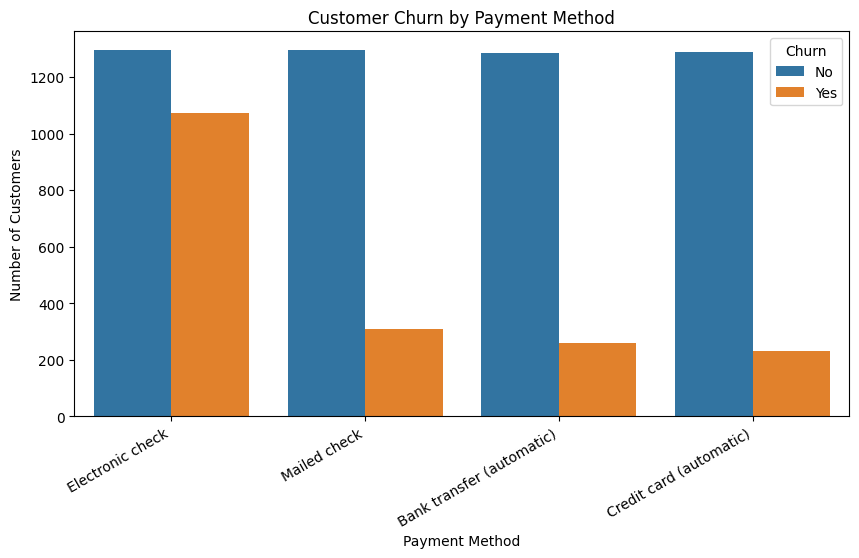

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

# 5. Logistic Regression – Customer Churn Prediction

### Business Objective

ABC Ltd. wants to identify customers who have a higher predicted
probability of churning.

### Dependent Variable

Churn

- Yes = 1
- No = 0

### Independent Variables

Customer demographic, service, contract and billing characteristics.

### Variables deliberately excluded

- customerID → identifier, not a meaningful predictor


In [24]:
logistic_df = df.copy()

# Remove customer identifier
logistic_df = logistic_df.drop(
    columns=["customerID"]
)

# Convert target into binary format
logistic_df["Churn"] = logistic_df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Logistic regression dataset shape:")
print(logistic_df.shape)

logistic_df.head()

Logistic regression dataset shape:
(7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [27]:
X_logistic = logistic_df.drop(
    columns=["Churn"]
)

y_logistic = logistic_df["Churn"]

print("Independent variables:", X_logistic.shape)
print("Dependent variable:", y_logistic.shape)

Independent variables: (7032, 19)
Dependent variable: (7032,)


In [28]:
categorical_features_logistic = (
    X_logistic
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

numerical_features_logistic = (
    X_logistic
    .select_dtypes(exclude=["object"])
    .columns
    .tolist()
)

print("Categorical variables:")
print(categorical_features_logistic)

print("\nNumerical variables:")
print(numerical_features_logistic)

Categorical variables:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical variables:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [35]:
from sklearn.model_selection import train_test_split

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_logistic,
    y_logistic,
    test_size=0.20,
    random_state=42,
    stratify=y_logistic
)

print("Training observations:", len(X_train_log))
print("Testing observations:", len(X_test_log))

Training observations: 5625
Testing observations: 1407


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_logistic = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features_logistic
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features_logistic
        )
    ]
)

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_logistic
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train_log,
    y_train_log
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [38]:
y_pred_logistic = logistic_model.predict(
    X_test_log
)

y_prob_logistic = logistic_model.predict_proba(
    X_test_log
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

log_accuracy = accuracy_score(
    y_test_log,
    y_pred_logistic
)

log_precision = precision_score(
    y_test_log,
    y_pred_logistic
)

log_recall = recall_score(
    y_test_log,
    y_pred_logistic
)

log_f1 = f1_score(
    y_test_log,
    y_pred_logistic
)

log_roc_auc = roc_auc_score(
    y_test_log,
    y_prob_logistic
)

logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        log_accuracy,
        log_precision,
        log_recall,
        log_f1,
        log_roc_auc
    ]
})

logistic_results["Value"] = (
    logistic_results["Value"].round(4)
)

logistic_results

,Metric,Value
0,Accuracy,0.8053
1,Precision,0.6515
2,Recall,0.5749
3,F1 Score,0.6108
4,ROC-AUC,0.8361


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_log,
        y_pred_logistic,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



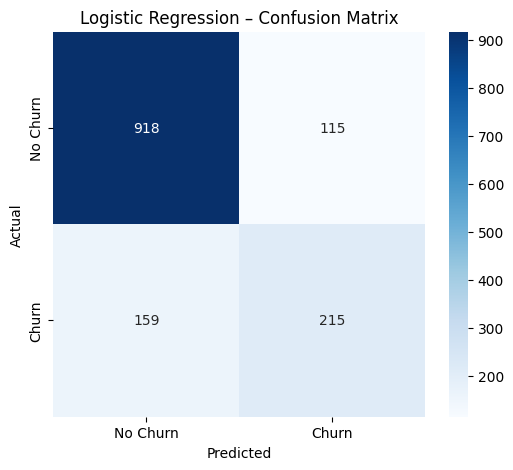

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_log,
    y_pred_logistic
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

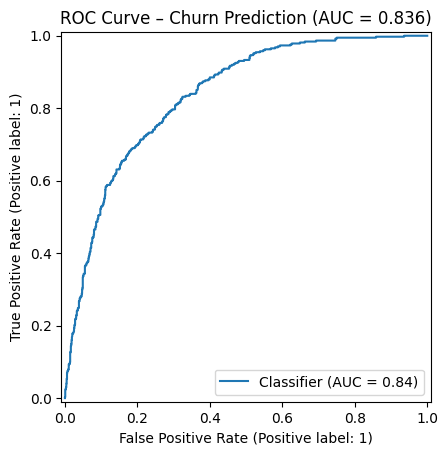

In [47]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test_log,
    y_prob_logistic
)

plt.title(
    f"ROC Curve – Churn Prediction "
    f"(AUC = {log_roc_auc:.3f})"
)

plt.show()

In [48]:
log_preprocessor_fitted = (
    logistic_model
    .named_steps["preprocessor"]
)

log_feature_names = (
    log_preprocessor_fitted
    .get_feature_names_out()
)

log_coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

log_feature_importance = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": log_coefficients,
    "Absolute_Coefficient": np.abs(log_coefficients)
})

log_feature_importance = (
    log_feature_importance
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

log_feature_importance.head(20)

,Feature,Coefficient,Absolute_Coefficient
25,categorical__Contract_Two year,-1.364823,1.364823
1,numerical__tenure,-1.357404,1.357404
10,categorical__InternetService_Fiber optic,1.107407,1.107407
24,categorical__Contract_One year,-0.750068,0.750068
3,numerical__TotalCharges,0.645508,0.645508
7,categorical__PhoneService_Yes,-0.515337,0.515337
2,numerical__MonthlyCharges,-0.434497,0.434497
28,categorical__PaymentMethod_Electronic check,0.379150,0.379150
13,categorical__OnlineSecurity_Yes,-0.373187,0.373187
21,categorical__StreamingTV_Yes,0.372407,0.372407


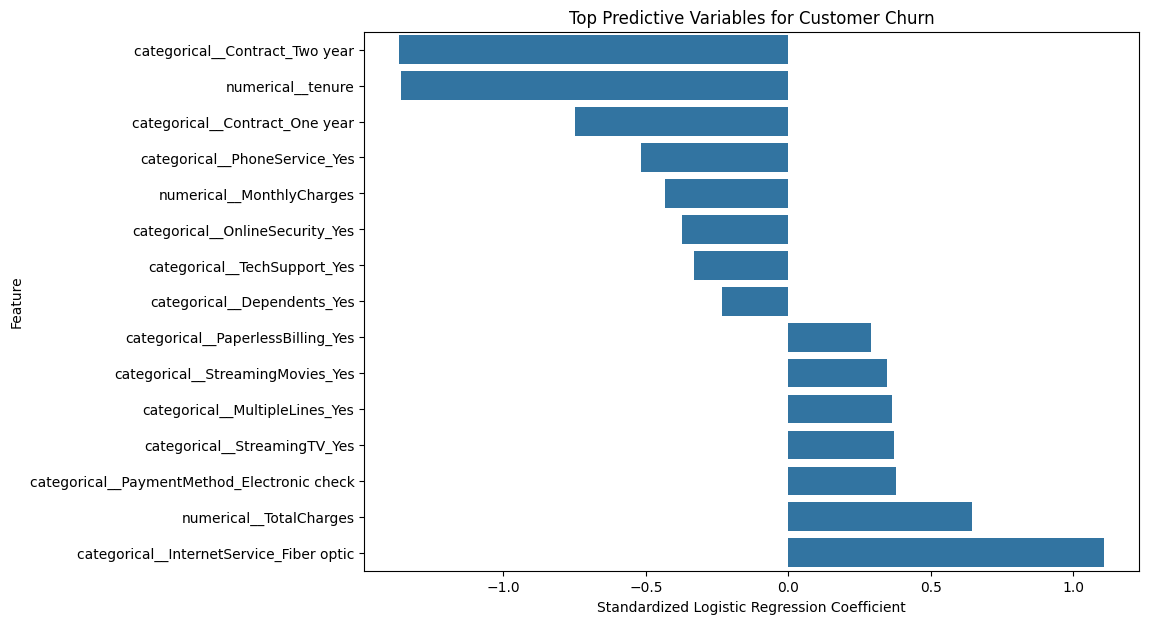

In [49]:
top_log_features = (
    log_feature_importance
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_log_features,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Predictive Variables for Customer Churn"
)

plt.xlabel(
    "Standardized Logistic Regression Coefficient"
)

plt.ylabel("Feature")

plt.show()

# 6. Linear Regression – Monthly Charge Prediction

### Business Objective

ABC Ltd. wants to estimate the expected monthly charge associated
with a customer's service configuration.

### Dependent Variable

MonthlyCharges

### Variables deliberately excluded

- customerID → identifier, not an independent variable
- MonthlyCharges → dependent variable
- TotalCharges → cumulative measure strongly related to monthly charges;
  excluded to avoid an overly mechanical relationship
- Churn → outcome variable from a separate prediction problem and not
  an appropriate predictor for estimating current monthly charges

In [50]:
linear_df = df.copy()

# Remove variables that should NOT be predictors
linear_df = linear_df.drop(
    columns=[
        "customerID",
        "TotalCharges",
        "Churn"
    ]
)

print("Variables used in Linear Regression:")
print(linear_df.columns.tolist())

Variables used in Linear Regression:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges']


In [51]:
X_linear = linear_df.drop(
    columns=["MonthlyCharges"]
)

y_linear = linear_df["MonthlyCharges"]

print("Independent variables:", X_linear.shape)
print("Dependent variable:", y_linear.shape)

Independent variables: (7032, 17)
Dependent variable: (7032,)


In [52]:
categorical_features_linear = (
    X_linear
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

numerical_features_linear = (
    X_linear
    .select_dtypes(exclude=["object"])
    .columns
    .tolist()
)

print("Categorical variables:")
print(categorical_features_linear)

print("\nNumerical variables:")
print(numerical_features_linear)


Categorical variables:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical variables:
['SeniorCitizen', 'tenure']


In [53]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_linear,
    y_linear,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train_lin))
print("Testing observations:", len(X_test_lin))

Training observations: 5625
Testing observations: 1407


In [54]:
preprocessor_linear = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features_linear
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features_linear
        )
    ]
)

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_linear
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train_lin,
    y_train_lin
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [57]:
y_pred_linear = linear_model.predict(
    X_test_lin
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

linear_mae = mean_absolute_error(
    y_test_lin,
    y_pred_linear
)

linear_mse = mean_squared_error(
    y_test_lin,
    y_pred_linear
)

linear_rmse = np.sqrt(
    linear_mse
)

linear_r2 = r2_score(
    y_test_lin,
    y_pred_linear
)

linear_results = pd.DataFrame({
    "Metric": [
        "R²",
        "MAE",
        "RMSE"
    ],
    "Value": [
        linear_r2,
        linear_mae,
        linear_rmse
    ]
})

linear_results["Value"] = (
    linear_results["Value"].round(4)
)

linear_results

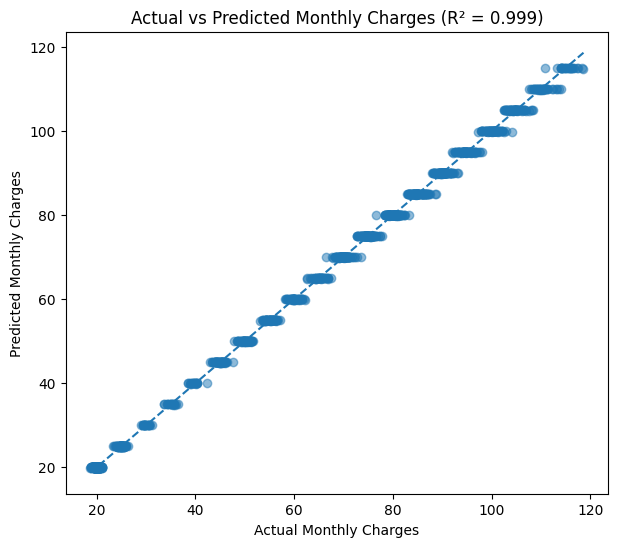

In [60]:
from sklearn.metrics import r2_score

# Recalculate linear_r2 to ensure it's defined in this scope
linear_r2 = r2_score(
    y_test_lin,
    y_pred_linear
)

plt.figure(figsize=(7,6))

plt.scatter(
    y_test_lin,
    y_pred_linear,
    alpha=0.5
)

# Reference line
min_value = min(
    y_test_lin.min(),
    y_pred_linear.min()
)

max_value = max(
    y_test_lin.max(),
    y_pred_linear.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Monthly Charges")
plt.ylabel("Predicted Monthly Charges")

plt.title(
    f"Actual vs Predicted Monthly Charges "
    f"(R² = {linear_r2:.3f})"
)

plt.show()

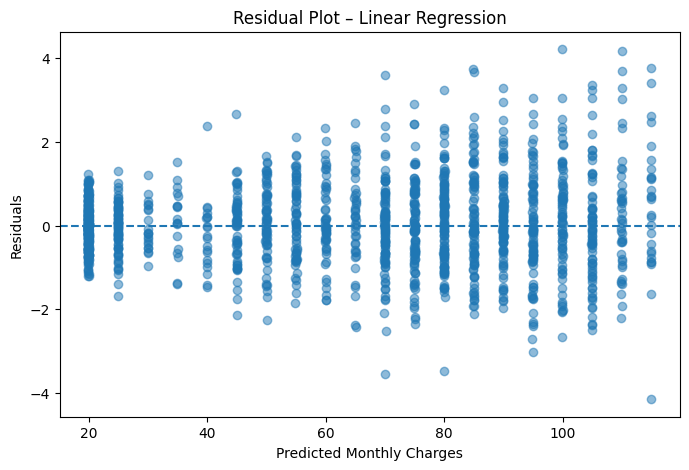

In [61]:
residuals = (
    y_test_lin - y_pred_linear
)

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_linear,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Monthly Charges")
plt.ylabel("Residuals")

plt.title(
    "Residual Plot – Linear Regression"
)

plt.show()

In [62]:
linear_preprocessor_fitted = (
    linear_model
    .named_steps["preprocessor"]
)

linear_feature_names = (
    linear_preprocessor_fitted
    .get_feature_names_out()
)

linear_coefficients = (
    linear_model
    .named_steps["model"]
    .coef_
)

linear_feature_importance = pd.DataFrame({
    "Feature": linear_feature_names,
    "Coefficient": linear_coefficients,
    "Absolute_Coefficient": np.abs(linear_coefficients)
})

linear_feature_importance = (
    linear_feature_importance
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

linear_feature_importance.head(20)

,Feature,Coefficient,Absolute_Coefficient
8,categorical__InternetService_Fiber optic,24.957837,24.957837
6,categorical__MultipleLines_No phone service,-10.017379,10.017379
5,categorical__PhoneService_Yes,10.017379,10.017379
21,categorical__StreamingMovies_Yes,9.964340,9.964340
19,categorical__StreamingTV_Yes,9.957688,9.957688
17,categorical__TechSupport_Yes,5.033800,5.033800
7,categorical__MultipleLines_Yes,5.027005,5.027005
11,categorical__OnlineSecurity_Yes,5.014558,5.014558
13,categorical__OnlineBackup_Yes,5.013779,5.013779
15,categorical__DeviceProtection_Yes,4.992427,4.992427


In [63]:
model_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear Regression"
    ],

    "Business Objective": [
        "Predict customer churn",
        "Predict monthly charges"
    ],

    "Main Evaluation Metric": [
        "ROC-AUC",
        "R²"
    ],

    "Score": [
        log_roc_auc,
        linear_r2
    ]
})

model_summary["Score"] = (
    model_summary["Score"].round(4)
)

model_summary

,Model,Business Objective,Main Evaluation Metric,Score
0,Logistic Regression,Predict customer churn,ROC-AUC,0.8361
1,Linear Regression,Predict monthly charges,R²,0.9988


In [64]:
def classify_risk(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.60:
        return "Medium"

    else:
        return "High"


def predict_customer(customer_data):

    # -------------------------
    # Churn prediction
    # -------------------------

    churn_probability = (
        logistic_model
        .predict_proba(customer_data)[0][1]
    )

    churn_prediction = (
        logistic_model
        .predict(customer_data)[0]
    )

    risk = classify_risk(
        churn_probability
    )

    # -------------------------
    # Monthly charge prediction
    # -------------------------

    linear_input = customer_data.drop(
        columns=["TotalCharges"],
        errors="ignore"
    ).copy()

    # Linear model was trained without these columns
    linear_input = linear_input.drop(
        columns=["Churn"],
        errors="ignore"
    )

    monthly_charge_prediction = (
        linear_model
        .predict(linear_input)[0]
    )

    return {
        "Churn Probability (%)":
            round(churn_probability * 100, 2),

        "Predicted Churn":
            "Yes" if churn_prediction == 1 else "No",

        "Risk Category":
            risk,

        "Predicted Monthly Charges":
            round(monthly_charge_prediction, 2)
    }

In [65]:
sample_customer = X_test_log.iloc[[0]].copy()

sample_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
974,Female,0,Yes,Yes,59,Yes,No,DSL,No,Yes,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),75.95,4542.35


In [66]:
prediction = predict_customer(
    sample_customer
)

prediction

{'Churn Probability (%)': np.float64(1.8),
 'Predicted Churn': 'No',
 'Risk Category': 'Low',
 'Predicted Monthly Charges': np.float64(74.9)}

In [67]:
manager_cases = X_test_log.sample(
    5,
    random_state=100
).copy()

manager_cases

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3720,Female,0,No,No,42,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Credit card (automatic),54.55,2455.05
4851,Female,1,No,No,3,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.40,204.70
4716,Female,0,Yes,No,66,Yes,Yes,DSL,Yes,Yes,Yes,No,No,No,Two year,No,Bank transfer (automatic),66.90,4370.25
2798,Male,0,No,No,10,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.90,1048.85
5418,Male,1,No,No,18,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic),80.55,1411.65


In [68]:
manager_results = []

for index, customer in manager_cases.iterrows():

    customer_df = pd.DataFrame(
        [customer]
    )

    result = predict_customer(
        customer_df
    )

    result["Case"] = f"Customer Case {len(manager_results) + 1}"

    manager_results.append(
        result
    )

manager_results_df = pd.DataFrame(
    manager_results
)

manager_results_df

,Churn Probability (%),Predicted Churn,Risk Category,Predicted Monthly Charges,Case
0,7.14,No,Low,54.98,Customer Case 1
1,72.34,Yes,High,69.97,Customer Case 2
2,0.88,No,Low,64.96,Customer Case 3
3,73.72,Yes,High,94.91,Customer Case 4
4,54.84,Yes,Medium,80.01,Customer Case 5


In [70]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [71]:
os.makedirs(
    "models",
    exist_ok=True
)

In [72]:
joblib.dump(
    logistic_model,
    "models/logistic_churn_model.pkl"
)

print(
    "Logistic Regression model saved."
)

Logistic Regression model saved.


In [73]:
joblib.dump(
    linear_model,
    "models/linear_monthly_charge_model.pkl"
)

print(
    "Linear Regression model saved."
)

Linear Regression model saved.


In [74]:
print(
    os.listdir("models")
)

['linear_monthly_charge_model.pkl', 'logistic_churn_model.pkl']


In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Re-calculate linear_mae and linear_rmse to ensure they are defined
linear_mae = mean_absolute_error(
    y_test_lin,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_lin,
        y_pred_linear
    )
)

model_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear Regression"
    ],

    "Objective": [
        "Predict Customer Churn",
        "Predict Monthly Charges"
    ],

    "Accuracy": [
        log_accuracy,
        np.nan
    ],

    "Precision": [
        log_precision,
        np.nan
    ],

    "Recall": [
        log_recall,
        np.nan
    ],

    "F1": [
        log_f1,
        np.nan
    ],

    "ROC_AUC": [
        log_roc_auc,
        np.nan
    ],

    "R2": [
        np.nan,
        linear_r2
    ],

    "MAE": [
        np.nan,
        linear_mae
    ],

    "RMSE": [
        np.nan,
        linear_rmse
    ]
})

model_metrics.round(4)

,Model,Objective,Accuracy,Precision,Recall,F1,ROC_AUC,R2,MAE,RMSE
0,Logistic Regression,Predict Customer Churn,0.8053,0.6515,0.5749,0.6108,0.8361,NaN,NaN,NaN
1,Linear Regression,Predict Monthly Charges,NaN,NaN,NaN,NaN,NaN,0.9988,0.7835,1.039


In [77]:
model_metrics.to_csv(
    "model_metrics.csv",
    index=False
)

print(
    "Model metrics saved as model_metrics.csv"
)

Model metrics saved as model_metrics.csv


In [ ]:
import shutil

shutil.make_archive(
    "ABC_Ltd_models",
    "zip",
    "models"
)

files.download(
    "ABC_Ltd_models.zip"
)

In [79]:
from google.colab import files

files.download(
    "model_metrics.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>